In [1]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from google.colab import drive, userdata

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
print("imports done")

imports done


In [2]:
drive.mount('/content/drive', force_remount=False)

base_path  = '/content/drive/MyDrive/ML/stock-lens/'
data_path  = base_path + 'data/'
model_path = base_path + 'models/'
os.makedirs(model_path, exist_ok=True)

print("paths set")

Mounted at /content/drive
paths set


In [3]:
# loading pre-split data saved from notebook 02
train = pd.read_csv(data_path + 'train.csv', parse_dates=['date'])
val   = pd.read_csv(data_path + 'val.csv',   parse_dates=['date'])
test  = pd.read_csv(data_path + 'test.csv',  parse_dates=['date'])

print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)
print("\nlabel distribution in train:")
print(train['label'].value_counts())

train: (575682, 32) | val: (124525, 32) | test: (126514, 32)

label distribution in train:
label
Neutral    326858
Up         132492
Down       116332
Name: count, dtype: int64


In [4]:
# defining which columns are features and which is the target
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'ma10', 'ma30', 'ma50', 'rsi', 'vol_ratio',
                'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
                'BBU_20_2.0_2.0', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
                'Earnings Per Share', 'Total Revenue', 'Net Income',
                'Total Assets', 'Total Liabilities', 'Profit Margin',
                'Total Equity', 'Operating Margin', 'Current Ratio']

target_col = 'label'

X_train = train[feature_cols]
y_train = train[target_col]

X_val   = val[feature_cols]
y_val   = val[target_col]

X_test  = test[feature_cols]
y_test  = test[target_col]

print("features:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

features: 25
X_train shape: (575682, 25)
X_val shape:   (124525, 25)
X_test shape:  (126514, 25)


In [5]:
# imputing nulls with column median — fundamental columns have many nulls
# using training set statistics only to prevent leakage
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# scaling features to zero mean and unit variance
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("imputing and scaling done")
print("any nulls remaining in X_train:", np.isnan(X_train).sum())

imputing and scaling done
any nulls remaining in X_train: 0


In [6]:
# encoding string labels to integers for model training
label_encoder = LabelEncoder()
y_train_enc   = label_encoder.fit_transform(y_train)
y_val_enc     = label_encoder.transform(y_val)
y_test_enc    = label_encoder.transform(y_test)

print("label classes:", label_encoder.classes_)
print("encoded values:", list(set(y_train_enc)))

label classes: ['Down' 'Neutral' 'Up']
encoded values: [np.int64(0), np.int64(1), np.int64(2)]


In [7]:
# training a random forest classifier as our baseline model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1                 # uses all available CPU cores
)

print("training random forest...")
rf_model.fit(X_train, y_train_enc)
print("done")

# evaluating on validation set
rf_val_preds = rf_model.predict(X_val)
print("\nrandom forest — validation results:")
print(classification_report(y_val_enc, rf_val_preds,
                            target_names=label_encoder.classes_))

training random forest...
done

random forest — validation results:
              precision    recall  f1-score   support

        Down       0.27      0.12      0.16     27715
     Neutral       0.61      0.70      0.65     69393
          Up       0.29      0.35      0.31     27417

    accuracy                           0.49    124525
   macro avg       0.39      0.39      0.38    124525
weighted avg       0.46      0.49      0.47    124525



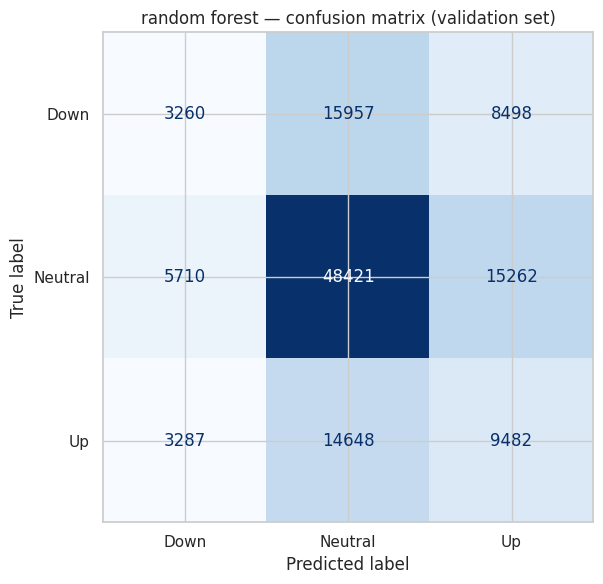

In [8]:
# visualizing which classes the random forest confuses
cm = confusion_matrix(y_val_enc, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('random forest — confusion matrix (validation set)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_17823/4281033505.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_df, palette='Blues_r')


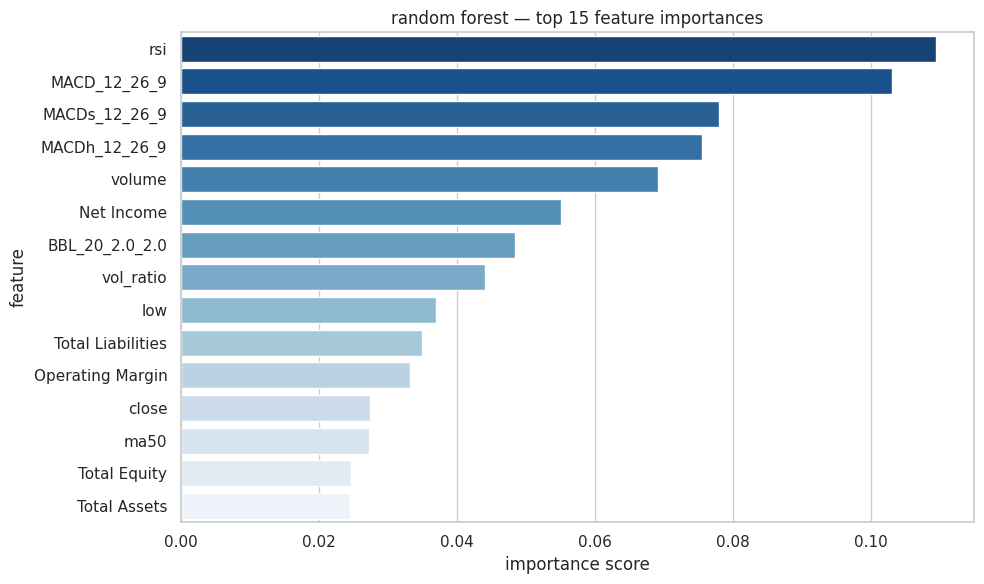

In [9]:
# showing which features the random forest found most useful
importances = rf_model.feature_importances_
feat_df     = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df     = feat_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_df, palette='Blues_r')
plt.title('random forest — top 15 feature importances')
plt.xlabel('importance score')
plt.tight_layout()
plt.show()

In [10]:
# training XGBoost as our primary classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

print("training XGBoost...")
xgb_model.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=50
)
print("done")

# evaluating on validation set
xgb_val_preds = xgb_model.predict(X_val)
print("\nXGBoost — validation results:")
print(classification_report(y_val_enc, xgb_val_preds,
                            target_names=label_encoder.classes_))

training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:18:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:0.99350
[50]	validation_0-mlogloss:0.97777
[100]	validation_0-mlogloss:0.97604
[150]	validation_0-mlogloss:0.97545
[199]	validation_0-mlogloss:0.97523
done

XGBoost — validation results:
              precision    recall  f1-score   support

        Down       0.39      0.01      0.02     27715
     Neutral       0.57      0.98      0.72     69393
          Up       0.38      0.04      0.08     27417

    accuracy                           0.56    124525
   macro avg       0.45      0.35      0.27    124525
weighted avg       0.49      0.56      0.42    124525



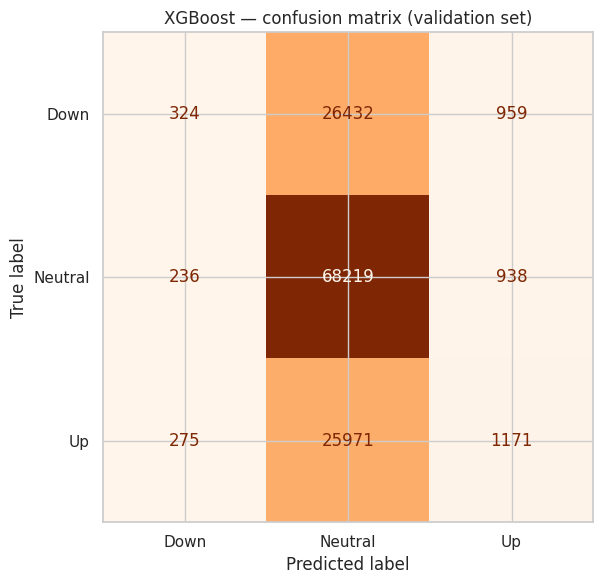

In [11]:
# visualizing which classes XGBoost confuses
cm = confusion_matrix(y_val_enc, xgb_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
plt.title('XGBoost — confusion matrix (validation set)')
plt.tight_layout()
plt.show()

        model  accuracy  macro_f1
Random Forest    0.4912    0.3761
      XGBoost    0.5598    0.2725


/tmp/ipykernel_17823/3078795616.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy', data=results, palette='Blues', ax=axes[0])
/tmp/ipykernel_17823/3078795616.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='macro_f1', data=results, palette='Greens', ax=axes[1])


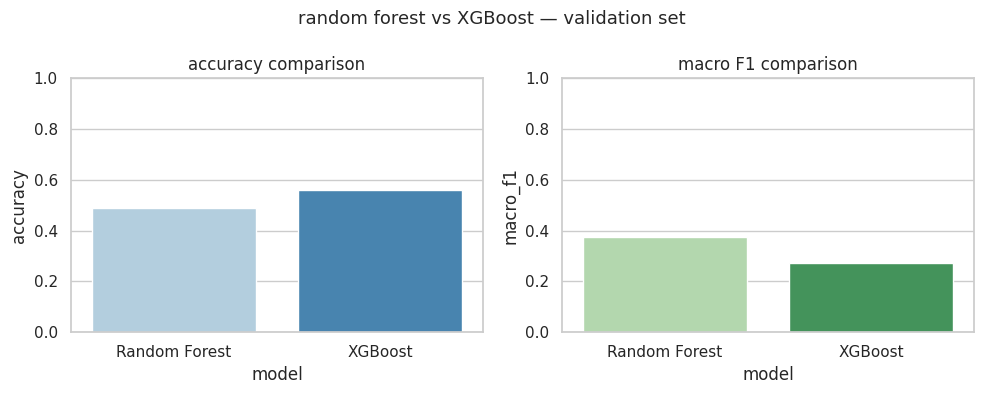

In [12]:
# comparing both models side by side on the validation set
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    'model':    ['Random Forest', 'XGBoost'],
    'accuracy': [accuracy_score(y_val_enc, rf_val_preds),
                 accuracy_score(y_val_enc, xgb_val_preds)],
    'macro_f1': [f1_score(y_val_enc, rf_val_preds,  average='macro'),
                 f1_score(y_val_enc, xgb_val_preds, average='macro')]
})

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x='model', y='accuracy', data=results, palette='Blues', ax=axes[0])
axes[0].set_title('accuracy comparison')
axes[0].set_ylim(0, 1)

sns.barplot(x='model', y='macro_f1', data=results, palette='Greens', ax=axes[1])
axes[1].set_title('macro F1 comparison')
axes[1].set_ylim(0, 1)

plt.suptitle('random forest vs XGBoost — validation set', fontsize=13)
plt.tight_layout()
plt.show()

XGBoost — final test set results:
              precision    recall  f1-score   support

        Down       0.36      0.01      0.03     25058
     Neutral       0.59      0.98      0.74     72746
          Up       0.39      0.06      0.10     28710

    accuracy                           0.58    126514
   macro avg       0.44      0.35      0.29    126514
weighted avg       0.50      0.58      0.45    126514



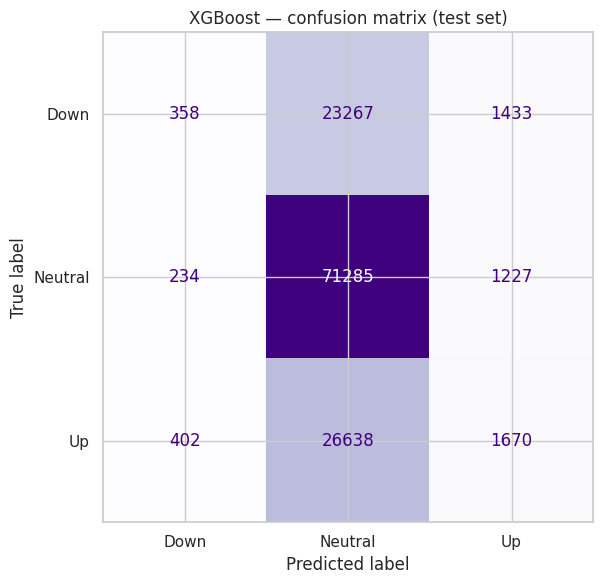

In [13]:
# running the best model on the held-out test set — only do this once
# using XGBoost as it typically outperforms RF on tabular data
xgb_test_preds = xgb_model.predict(X_test)

print("XGBoost — final test set results:")
print(classification_report(y_test_enc, xgb_test_preds,
                            target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test_enc, xgb_test_preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                  display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Purples', colorbar=False)
plt.title('XGBoost — confusion matrix (test set)')
plt.tight_layout()
plt.show()

Random Forest — final test set results:
              precision    recall  f1-score   support

        Down       0.25      0.13      0.17     25058
     Neutral       0.64      0.70      0.67     72746
          Up       0.30      0.35      0.32     28710

    accuracy                           0.51    126514
   macro avg       0.40      0.39      0.39    126514
weighted avg       0.49      0.51      0.49    126514



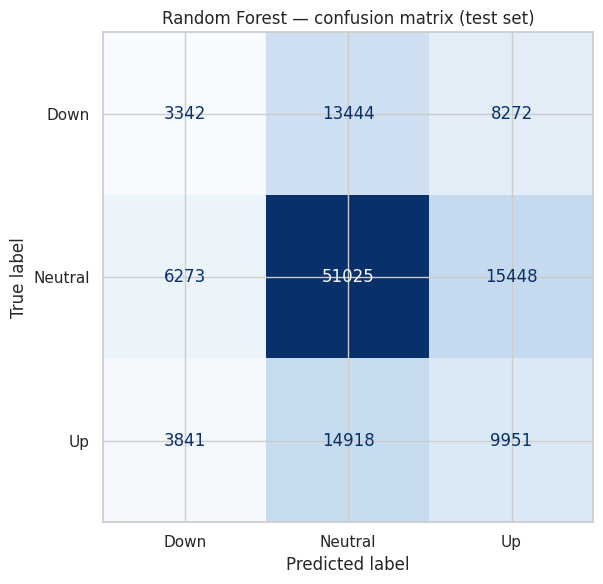

In [14]:
# evaluating random forest on the held-out test set
rf_test_preds = rf_model.predict(X_test)

print("Random Forest — final test set results:")
print(classification_report(y_test_enc, rf_test_preds,
                            target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test_enc, rf_test_preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                  display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — confusion matrix (test set)')
plt.tight_layout()
plt.show()

In [15]:
# saving all models and preprocessing objects for use in the chatbot notebook
with open(model_path + 'rf_model.pkl',       'wb') as f: pickle.dump(rf_model,       f)
with open(model_path + 'xgb_model.pkl',      'wb') as f: pickle.dump(xgb_model,      f)
with open(model_path + 'scaler.pkl',         'wb') as f: pickle.dump(scaler,         f)
with open(model_path + 'imputer.pkl',        'wb') as f: pickle.dump(imputer,        f)
with open(model_path + 'label_encoder.pkl',  'wb') as f: pickle.dump(label_encoder,  f)
with open(model_path + 'feature_cols.pkl',   'wb') as f: pickle.dump(feature_cols,   f)

print("saved models")
print("files in models folder:")
print(os.listdir(model_path))

saved models
files in models folder:
['rf_model.pkl', 'xgb_model.pkl', 'scaler.pkl', 'imputer.pkl', 'label_encoder.pkl', 'feature_cols.pkl']


In [ ]:
import os
import json
from google.colab import drive, _message, userdata

# pulling credentials from colab secrets
github_token = userdata.get('GITHUB_TOKEN')
github_email = userdata.get('GITHUB_EMAIL')
github_name  = userdata.get('GITHUB_NAME')

# saving the notebook to google drive
notebook_name = '03_classification'
notebook_path = f'/content/drive/MyDrive/ML/stock-lens/notebooks/{notebook_name}.ipynb'

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=120)
with open(notebook_path, 'w') as f:
    json.dump(notebook_json['ipynb'], f)
print("saved to drive")

# installing pdf conversion dependencies
os.system('apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q')
os.system('pip install -q nbconvert[webpdf] playwright')
os.system('playwright install chromium')

# converting notebook to pdf
os.system(f'jupyter nbconvert --to webpdf --allow-chromium-download "{notebook_path}"')
pdf_path = notebook_path.replace('.ipynb', '.pdf')
print("pdf created!!" if os.path.exists(pdf_path) else "pdf creation failed")

# cloning repo if not already present
repo_path = '/content/stock-lens'
if not os.path.exists(repo_path):
    os.system(f'git clone https://github.com/SidRoy97/stock-lens.git {repo_path}')

# creating notebooks folder if missing
os.makedirs(f'{repo_path}/notebooks', exist_ok=True)

# copying notebook and pdf into repo
os.system(f'cp "{notebook_path}" "{repo_path}/notebooks/{notebook_name}.ipynb"')
if os.path.exists(pdf_path):
    os.system(f'cp "{pdf_path}" "{repo_path}/notebooks/{notebook_name}.pdf"')

# configuring git with user credentials
os.system(f'git -C {repo_path} config user.email "{github_email}"')
os.system(f'git -C {repo_path} config user.name "{github_name}"')
os.system(f'git -C {repo_path} add notebooks/')

commit = os.popen(f'git -C {repo_path} commit -m "update {notebook_name} notebook and pdf" 2>&1').read()
print("commit:", commit)

# pushing to github
remote = f'https://{github_token}@github.com/SidRoy97/stock-lens.git'
push   = os.popen(f'git -C {repo_path} push {remote} main 2>&1').read()
print("push:", push)